# Лабораторная работа №6
## Очистка и трансформация данных. pandas

**Выполнил:** Корнеев Фёдор  
**Группа:** P3120

## 1. Введение

В реальных данных встречаются пропуски, неверные типы и экстремальные значения.
До анализа или машинного обучения такие данные нужно проверить, очистить и
привести к удобному формату. В работе эти действия выполняются средствами
`pandas` на наборе Titanic.

## 2. Цель работы

Освоить первичный анализ, заполнение пропусков, изменение типов, создание новых
признаков, обработку выбросов, агрегацию и оценку качества очистки данных.

## 3. Описание набора данных

Используется обучающая часть набора Titanic из соревнования Kaggle. Одна строка
соответствует пассажиру. Цель `Survived` показывает факт выживания. Остальные
поля описывают класс билета, имя, пол, возраст, родственников, билет, стоимость,
каюту и порт посадки.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_URL = (
    "https://raw.githubusercontent.com/datasciencedojo/"
    "datasets/master/titanic.csv"
)
DATA_FILE = Path("titanic.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

if not DATA_FILE.exists():
    urlretrieve(DATA_URL, DATA_FILE)

raw_data = pd.read_csv(DATA_FILE)
data = raw_data.copy()
print(f"Размер набора данных: {data.shape[0]} строк, {data.shape[1]} столбцов")

Размер набора данных: 891 строк, 12 столбцов


## 4. Первичный анализ

In [2]:
# Первые десять пассажиров.
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# Типы данных и количество заполненных значений.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
missing_before = data.isna().sum().sort_values(ascending=False)
missing_before.to_frame("Количество пропусков")

,Количество пропусков
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


## 5. Статистика датафрейма

In [5]:
data.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


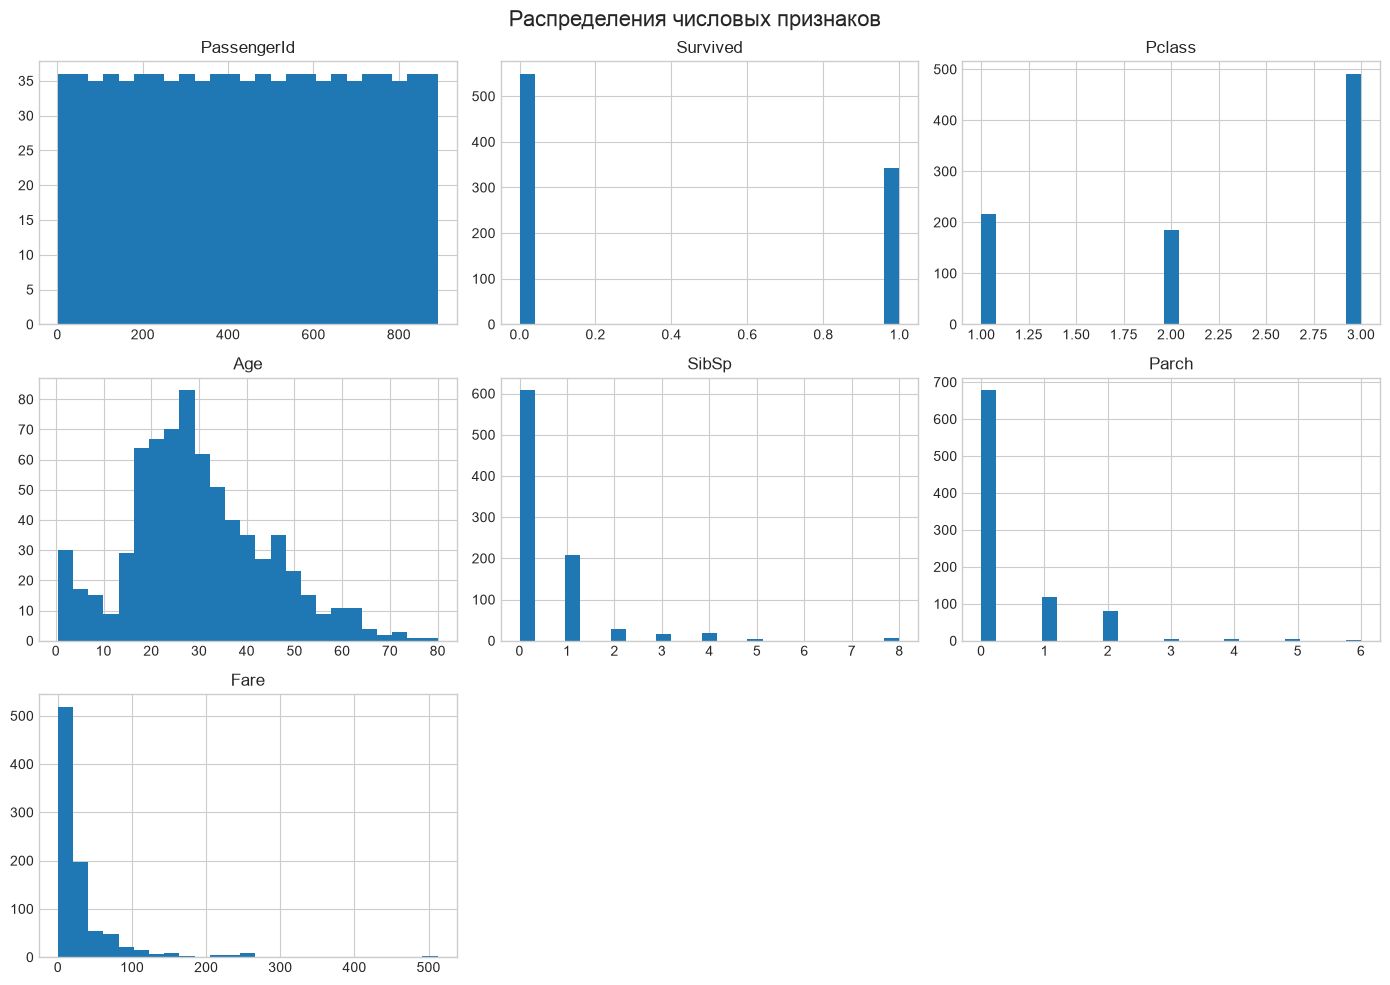

In [6]:
numeric_columns = data.select_dtypes(include="number").columns
axes = data[numeric_columns].hist(figsize=(14, 10), bins=25)
plt.suptitle("Распределения числовых признаков", fontsize=16)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "numeric_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Визуализация пропусков

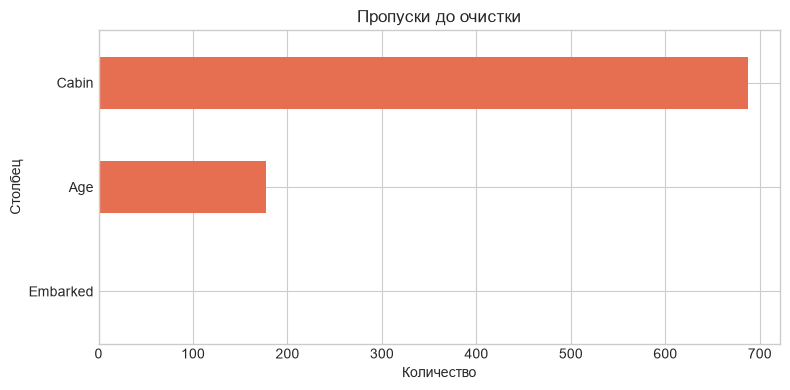

In [7]:
missing_nonzero = missing_before[missing_before > 0]
ax = missing_nonzero.sort_values().plot(
    kind="barh",
    color="#e76f51",
    figsize=(8, 4),
)
ax.set_title("Пропуски до очистки")
ax.set_xlabel("Количество")
ax.set_ylabel("Столбец")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "missing_before.png", dpi=160, bbox_inches="tight")
plt.show()

Больше всего пропусков находится в `Cabin`, поэтому восстановить точный номер
каюты нельзя. В `Age` пропуски заполняются медианой: она устойчивее среднего к
крайним значениям. В `Embarked` отсутствуют только два значения, поэтому
используется мода.

## 7. Обработка пропусков

In [8]:
age_mean = data["Age"].mean()
age_median = data["Age"].median()
embarked_mode = data["Embarked"].mode().iloc[0]

print(f"Средний возраст: {age_mean:.2f}")
print(f"Медианный возраст: {age_median:.2f}")
print(f"Мода Embarked: {embarked_mode}")

Средний возраст: 29.70
Медианный возраст: 28.00
Мода Embarked: S


## 8. Методы заполнения

In [9]:
data["Age"] = data["Age"].fillna(age_median)
data["Age_group"] = pd.cut(
    data["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teen", "Young adult", "Adult", "Senior"],
    include_lowest=True,
)

data["Embarked"] = data["Embarked"].fillna(embarked_mode)

# Вместо почти пустого номера каюты сохраняем только палубу.
# U означает, что каюта неизвестна.
data["Deck"] = data["Cabin"].str[0].fillna("U")
data = data.drop(columns="Cabin")

## 9. Результаты обработки пропусков

In [10]:
missing_after_fill = data.isna().sum()
print("Осталось пропусков:", int(missing_after_fill.sum()))
print("Распределение возрастных групп:")
display(data["Age_group"].value_counts().sort_index())
print("Распределение палуб:")
display(data["Deck"].value_counts())

Осталось пропусков: 0
Распределение возрастных групп:


Age_group
Child           69
Teen            70
Young adult    535
Adult          195
Senior          22
Name: count, dtype: int64

Распределение палуб:


Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

## 10. Трансформация данных

In [11]:
# Pclass переводится в строковые категории по условию задания.
class_mapping = {1: "F", 2: "S", 3: "T"}
data["Pclass"] = data["Pclass"].map(class_mapping).astype("category")

# Из имени извлекается обращение между запятой и точкой.
data["Title"] = data["Name"].str.extract(r",\s*([^.]*)\.", expand=False)
common_titles = {"Mr", "Miss", "Mrs", "Master"}
data["Title"] = data["Title"].where(
    data["Title"].isin(common_titles),
    "Rare",
).astype("category")

data["Sex"] = data["Sex"].map({"female": 0, "male": 1}).astype("int8")
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
data["IsAlone"] = (data["FamilySize"] == 1).astype("int8")
data["Embarked"] = data["Embarked"].astype("category")
data["Deck"] = data["Deck"].astype("category")

## 11. Созданные признаки

In [12]:
created_columns = ["Age_group", "Deck", "Title", "FamilySize", "IsAlone"]
data[created_columns].head(10)

,Age_group,Deck,Title,FamilySize,IsAlone
0,Young adult,U,Mr,2,0
1,Adult,C,Mrs,2,0
2,Young adult,U,Miss,1,1
3,Young adult,C,Mrs,2,0
4,Young adult,U,Mr,1,1
5,Young adult,U,Mr,1,1
6,Adult,E,Mr,1,1
7,Child,U,Master,5,0
8,Young adult,U,Mrs,3,0
9,Teen,U,Mrs,2,0


In [13]:
print("Обращения:")
display(data["Title"].value_counts())
print("Размер семьи:")
display(data["FamilySize"].value_counts().sort_index())
print("Пассажиры без семьи на борту:", int(data["IsAlone"].sum()))

Обращения:


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Размер семьи:


FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Пассажиры без семьи на борту: 537


## 12. Преобразования типов

In [14]:
data[["Pclass", "Sex", "Embarked", "Age_group", "Deck", "Title"]].dtypes

Pclass       category
Sex              int8
Embarked     category
Age_group    category
Deck         category
Title        category
dtype: object

## 13. Обработка выбросов

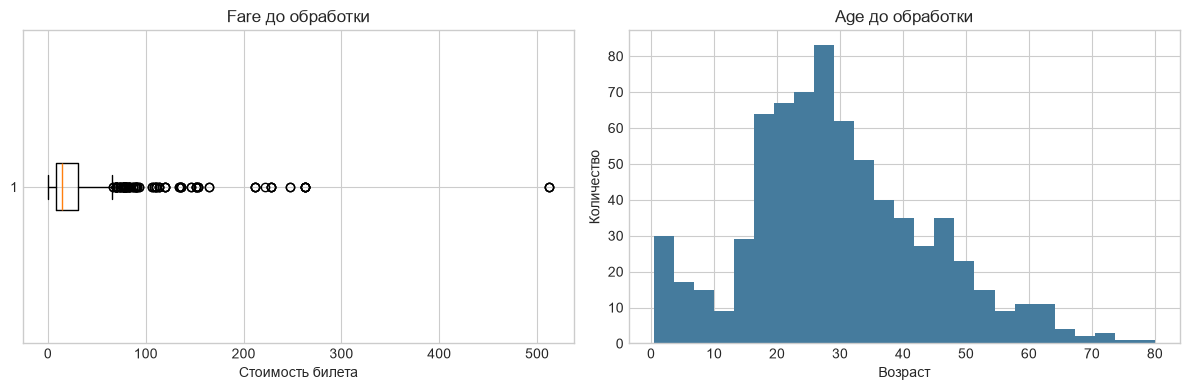

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(raw_data["Fare"].dropna(), orientation="horizontal")
axes[0].set_title("Fare до обработки")
axes[0].set_xlabel("Стоимость билета")

axes[1].hist(raw_data["Age"].dropna(), bins=25, color="#457b9d")
axes[1].set_title("Age до обработки")
axes[1].set_xlabel("Возраст")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "outliers_before.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Выявленные выбросы

In [16]:
fare_q1 = raw_data["Fare"].quantile(0.25)
fare_q3 = raw_data["Fare"].quantile(0.75)
fare_iqr = fare_q3 - fare_q1
fare_lower_iqr = fare_q1 - 1.5 * fare_iqr
fare_upper_iqr = fare_q3 + 1.5 * fare_iqr
fare_outlier_mask = ~raw_data["Fare"].between(
    fare_lower_iqr,
    fare_upper_iqr,
)

print(f"Q1 Fare: {fare_q1:.4f}")
print(f"Q3 Fare: {fare_q3:.4f}")
print(f"IQR Fare: {fare_iqr:.4f}")
print(f"Границы IQR: {fare_lower_iqr:.4f} .. {fare_upper_iqr:.4f}")
print(f"Выбросов Fare по IQR: {int(fare_outlier_mask.sum())}")

Q1 Fare: 7.9104
Q3 Fare: 31.0000
IQR Fare: 23.0896
Границы IQR: -26.7240 .. 65.6344
Выбросов Fare по IQR: 116


## 15. Методы обработки выбросов

In [17]:
# Винзоризация Fare: ограничиваем значения 5-м и 95-м перцентилями.
fare_p05 = data["Fare"].quantile(0.05)
fare_p95 = data["Fare"].quantile(0.95)
data["Fare"] = data["Fare"].clip(lower=fare_p05, upper=fare_p95)

# По условию задания экстремальный возраст ограничивается 95-м перцентилем.
age_p95 = data["Age"].quantile(0.95)
ages_capped = int((data["Age"] > age_p95).sum())
data["Age"] = data["Age"].clip(upper=age_p95)

print(f"Границы winsorization Fare: {fare_p05:.4f} .. {fare_p95:.4f}")
print(f"95-й перцентиль Age: {age_p95:.2f}")
print(f"Заменено экстремальных значений Age: {ages_capped}")

Границы winsorization Fare: 7.2250 .. 112.0791
95-й перцентиль Age: 54.00
Заменено экстремальных значений Age: 42


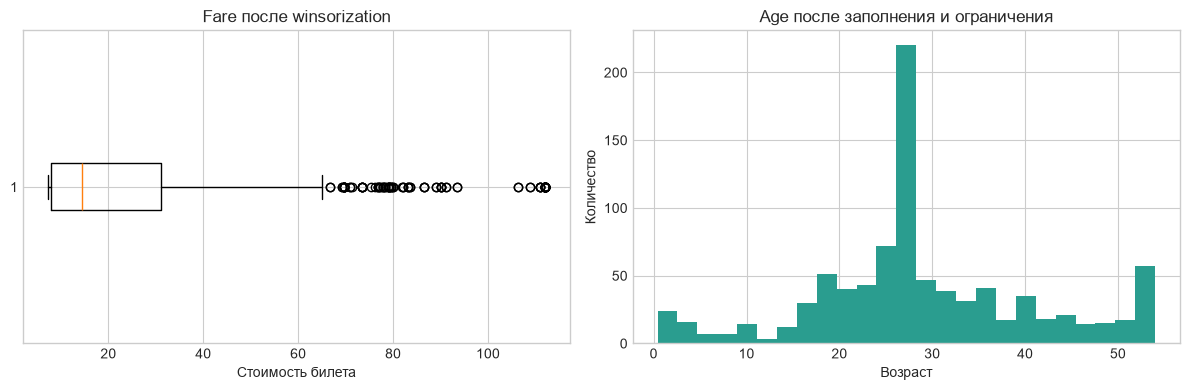

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(data["Fare"], orientation="horizontal")
axes[0].set_title("Fare после winsorization")
axes[0].set_xlabel("Стоимость билета")

axes[1].hist(data["Age"], bins=25, color="#2a9d8f")
axes[1].set_title("Age после заполнения и ограничения")
axes[1].set_xlabel("Возраст")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "outliers_after.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Агрегация и анализ

In [19]:
survival_by_class = data.groupby(
    "Pclass",
    observed=True,
)["Survived"].mean()

survival_by_class_and_sex = data.groupby(
    ["Pclass", "Sex"],
    observed=True,
)["Survived"].agg(["count", "mean"])

median_age_by_port = data.groupby(
    "Embarked",
    observed=True,
)["Age"].median()

print("Средняя выживаемость по классам:")
display(survival_by_class.to_frame("survival_rate"))
print("Выживаемость по классу и полу (0 — женщина, 1 — мужчина):")
display(survival_by_class_and_sex)
print("Медианный возраст по портам:")
display(median_age_by_port.to_frame("median_age"))

Средняя выживаемость по классам:


,survival_rate
Pclass,
F,0.629630
S,0.472826
T,0.242363


Выживаемость по классу и полу (0 — женщина, 1 — мужчина):


count      mean
Pclass Sex                 
F      0       94  0.968085
       1      122  0.368852
S      0       76  0.921053
       1      108  0.157407
T      0      144  0.500000
       1      347  0.135447

Медианный возраст по портам:


,median_age
Embarked,
C,28.0
Q,28.0
S,28.0


## 17. Сводные статистики

In [20]:
survival_pivot = pd.pivot_table(
    data,
    values="Survived",
    index=["Pclass", "Age_group"],
    columns="Sex",
    aggfunc="mean",
    observed=True,
)
survival_pivot.columns = ["female", "male"]
survival_pivot.round(3)

female   male
Pclass Age_group                 
F      Child         0.000  1.000
       Teen          1.000  0.500
       Young adult   0.978  0.392
       Adult         0.972  0.370
       Senior        1.000  0.083
S      Child         1.000  1.000
       Teen          1.000  0.000
       Young adult   0.929  0.095
       Adult         0.850  0.037
       Senior          NaN  0.333
T      Child         0.478  0.360
       Teen          0.550  0.077
       Young adult   0.547  0.133
       Adult         0.143  0.068
       Senior        1.000  0.000

## 18. Визуализации

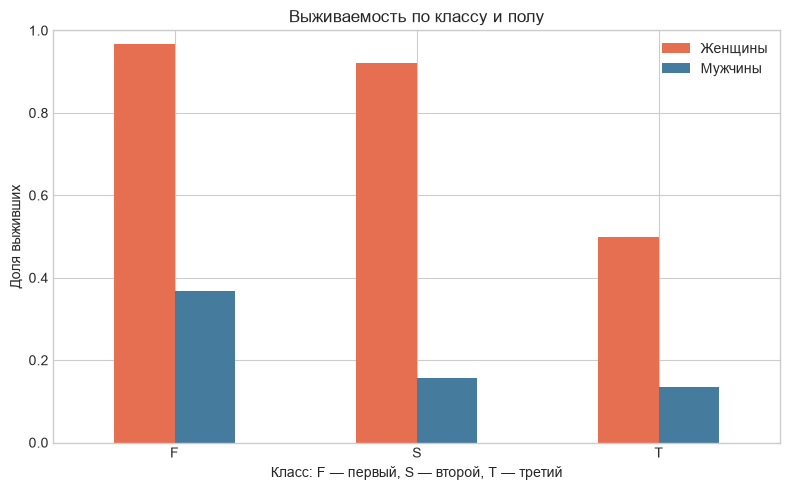

In [21]:
plot_data = survival_by_class_and_sex["mean"].unstack("Sex")
plot_data.columns = ["Женщины", "Мужчины"]
ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#e76f51", "#457b9d"],
)
ax.set_title("Выживаемость по классу и полу")
ax.set_xlabel("Класс: F — первый, S — второй, T — третий")
ax.set_ylabel("Доля выживших")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "survival_by_class_sex.png", dpi=160, bbox_inches="tight")
plt.show()

## 19. Метрики качества очистки

In [22]:
initial_missing_count = int(raw_data.isna().sum().sum())
remaining_missing_count = int(data.isna().sum().sum())
filled_missing_percent = (
    (initial_missing_count - remaining_missing_count)
    / initial_missing_count
    * 100
)
completeness_before = (1 - initial_missing_count / raw_data.size) * 100
completeness_after = (1 - remaining_missing_count / data.size) * 100

print(f"Пропусков до обработки: {initial_missing_count}")
print(f"Пропусков после обработки: {remaining_missing_count}")
print(f"Заполнено/обработано пропусков: {filled_missing_percent:.2f}%")
print(f"Полнота исходных данных: {completeness_before:.2f}%")
print(f"Полнота очищенных данных: {completeness_after:.2f}%")

Пропусков до обработки: 866
Пропусков после обработки: 0
Заполнено/обработано пропусков: 100.00%
Полнота исходных данных: 91.90%
Полнота очищенных данных: 100.00%


In [23]:
categorical_columns = [
    "Pclass",
    "Embarked",
    "Age_group",
    "Deck",
    "Title",
]
unique_categories = data[categorical_columns].nunique().to_frame(
    "Уникальных значений"
)
unique_categories

,Уникальных значений
Pclass,3
Embarked,3
Age_group,5
Deck,9
Title,5


In [24]:
distribution_after = pd.DataFrame(
    {
        "Sex": data["Sex"].value_counts(normalize=True),
        "IsAlone": data["IsAlone"].value_counts(normalize=True),
        "Survived": data["Survived"].value_counts(normalize=True),
    }
).fillna(0)
distribution_after.index.name = "Значение"
distribution_after.round(4)

,Sex,IsAlone,Survived
Значение,,,
0,0.3524,0.3973,0.6162
1,0.6476,0.6027,0.3838


In [25]:
correlation_columns = [
    "Age",
    "Fare",
    "Sex",
    "FamilySize",
    "IsAlone",
    "Survived",
]
new_feature_correlation = data[correlation_columns].corr()
new_feature_correlation.round(3)

,Age,Fare,Sex,FamilySize,IsAlone,Survived
Age,1.000,0.135,0.074,-0.255,0.174,-0.062
Fare,0.135,1.000,-0.237,0.304,-0.394,0.313
Sex,0.074,-0.237,1.000,-0.201,0.304,-0.543
FamilySize,-0.255,0.304,-0.201,1.000,-0.691,0.017
IsAlone,0.174,-0.394,0.304,-0.691,1.000,-0.203
Survived,-0.062,0.313,-0.543,0.017,-0.203,1.000


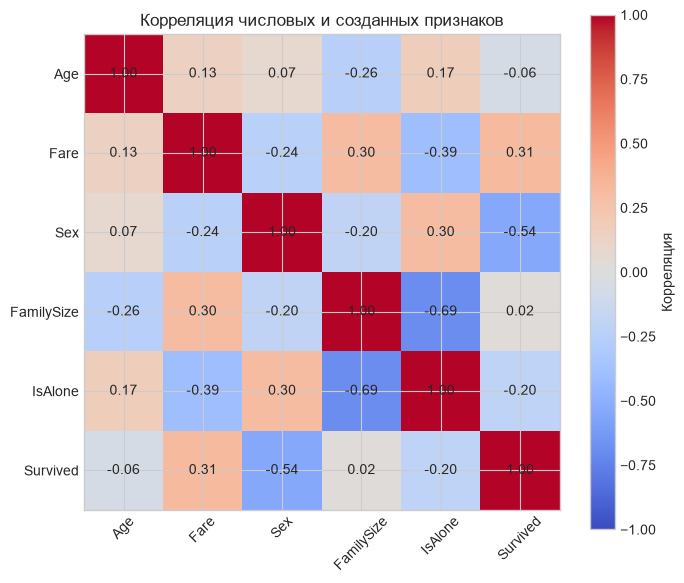

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(new_feature_correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_columns)), correlation_columns, rotation=45)
ax.set_yticks(range(len(correlation_columns)), correlation_columns)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        value = new_feature_correlation.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Корреляция")
ax.set_title("Корреляция числовых и созданных признаков")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "correlation.png", dpi=160, bbox_inches="tight")
plt.show()

## 20. Результаты работы

In [27]:
OUTPUT_FILE = Path("titanic_cleaned.csv")
data.to_csv(OUTPUT_FILE, index=False)

print(f"Очищенные данные сохранены в {OUTPUT_FILE}")
print(f"Итоговый размер: {data.shape[0]} строк, {data.shape[1]} столбцов")
data.head()

Очищенные данные сохранены в titanic_cleaned.csv
Итоговый размер: 891 строк, 16 столбцов


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_group,Deck,Title,FamilySize,IsAlone
0,1,0,T,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,Young adult,U,Mr,2,0
1,2,1,F,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,Adult,C,Mrs,2,0
2,3,1,T,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,Young adult,U,Miss,1,1
3,4,1,F,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,Young adult,C,Mrs,2,0
4,5,0,T,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,Young adult,U,Mr,1,1


## 21. Выводы

В исходном наборе найдено 866 пропущенных значений. Возраст заполнен медианой,
порт посадки — модой, а из номера каюты создан более устойчивый признак палубы.
После обработки пропусков не осталось. Созданы признаки возрастной группы,
обращения, размера семьи и одиночного путешествия; класс билета и категориальные
поля приведены к нужным типам.

IQR-метод обнаружил выбросы стоимости билета. Для `Fare` применена двусторонняя
winsorization по 5-му и 95-му перцентилям, а возраст ограничен сверху 95-м
перцентилем. Агрегация показала более высокую выживаемость в первом классе и у
женщин. Очищенный набор сохранён в CSV и готов к дальнейшему анализу или
построению модели.